# Fail2Drive result analysis

This notebook reads `results/<run>/<seed>/res/*_res.json`, identifies each route's scenario family from `fail2drive_split`, and compares Base with Generalization. A positive **degradation** means the Generalization average is lower than Base.

In [1]:
from __future__ import annotations

import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid', context='notebook')

# Run this notebook from the fail2drive directory, or adjust PROJECT_ROOT.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'results').exists():
    PROJECT_ROOT = PROJECT_ROOT / 'fail2drive'

RESULTS_ROOT = PROJECT_ROOT / 'results'
SPLIT_ROOT = PROJECT_ROOT / 'fail2drive_split'

# Set RUNS to a list such as ['hipad', 'hipad_oracle_new_2']; use None for every run.
RUNS = ['hipad', 'hipad_oracle_new_6']
SEEDS = [1]  # Use None for every available seed.
FINISHED_ONLY = True

assert RESULTS_ROOT.exists(), f'Missing results directory: {RESULTS_ROOT}'
assert SPLIT_ROOT.exists(), f'Missing split directory: {SPLIT_ROOT}'


In [2]:
ROUTE_RE = re.compile(r'^(Base|Generalization)_(.+)_(\d{4})\.xml$')

route_metadata = {}
for route_path in SPLIT_ROOT.glob('*.xml'):
    match = ROUTE_RE.match(route_path.name)
    if not match:
        continue
    split, family, case_id = match.groups()
    route_metadata[case_id] = {
        'split': split,
        'family': family,
        'route_file': route_path.name,
    }

def number_or_none(value):
    return None if value is None else float(value)

rows = []
for result_path in RESULTS_ROOT.glob('*/*/res/*_res.json'):
    # .../results/<run>/<seed>/res/<case>_res.json
    run, seed = result_path.parents[2].name, result_path.parents[1].name
    if RUNS is not None and run not in RUNS:
        continue
    if SEEDS is not None and seed not in {str(item) for item in SEEDS}:
        continue
    case_id = result_path.stem.removesuffix('_res')
    with result_path.open() as handle:
        result = json.load(handle)
    record = result.get('_checkpoint', {}).get('global_record', {})
    score = record.get('scores_mean', {})
    infractions = record.get('infractions', {})
    rows.append({
        'run': run, 'seed': int(seed), 'case_id': case_id,
        'entry_status': result.get('entry_status'), 'eligible': result.get('eligible'),
        'record_status': record.get('status'),
        'driving_score': number_or_none(score.get('score_composed')),
        'route_completion': number_or_none(score.get('score_route')),
        'infraction_penalty': number_or_none(score.get('score_penalty')),
        'collisions_vehicle': number_or_none(infractions.get('collisions_vehicle')),
        'collisions_pedestrian': number_or_none(infractions.get('collisions_pedestrian')),
        'collisions_layout': number_or_none(infractions.get('collisions_layout')),
        'min_speed_infractions': number_or_none(infractions.get('min_speed_infractions')),
        **route_metadata.get(case_id, {'split': 'Unknown', 'family': 'Unknown', 'route_file': None}),
    })

results = pd.DataFrame(rows)
assert not results.empty, 'No result JSON files matched the selected RUNS and SEEDS.'
results = results.sort_values(['run', 'seed', 'case_id']).reset_index(drop=True)
results.head()


,run,seed,case_id,entry_status,eligible,record_status,driving_score,route_completion,infraction_penalty,collisions_vehicle,collisions_pedestrian,collisions_layout,min_speed_infractions,split,family,route_file
0,hipad,1,0000,Finished,True,Completed,66.794427,100.0,0.667944,0.00,0.0,0.0,17.055,Base,BadParking,Base_BadParking_0000.xml
1,hipad,1,0001,Finished,True,Completed,50.703533,100.0,0.507035,5.77,0.0,0.0,11.541,Base,BadParking,Base_BadParking_0001.xml
2,hipad,1,0002,Finished,True,Completed,77.464044,100.0,0.774640,0.00,0.0,0.0,9.994,Base,BadParking,Base_BadParking_0002.xml
3,hipad,1,0003,Finished,True,Completed,63.376402,100.0,0.633764,0.00,0.0,0.0,14.528,Base,BadParking,Base_BadParking_0003.xml
4,hipad,1,0004,Finished,True,Completed,46.015371,100.0,0.460154,0.00,0.0,0.0,12.750,Base,BadParking,Base_BadParking_0004.xml


In [3]:
# Verify completeness before comparing metrics.
completeness = (results.groupby(['run', 'seed'])
    .agg(cases=('case_id', 'size'),
         finished=('entry_status', lambda s: (s == 'Finished').sum()),
         eligible=('eligible', 'sum'),
         base_cases=('split', lambda s: (s == 'Base').sum()),
         generalization_cases=('split', lambda s: (s == 'Generalization').sum()))
    .reset_index())
display(completeness)

analysis = results.copy()
if FINISHED_ONLY:
    analysis = analysis.query("entry_status == 'Finished' and eligible == True").copy()

print(f'Analysing {len(analysis)} finished, eligible route results.')
unfinished = results.query("entry_status != 'Finished' or eligible != True")
display(unfinished[['run', 'seed', 'case_id', 'route_file', 'entry_status', 'eligible']])


,run,seed,cases,finished,eligible,base_cases,generalization_cases
0,hipad,1,200,198,198,100,100
1,hipad_oracle_new_6,1,200,196,196,100,100


Analysing 394 finished, eligible route results.


,run,seed,case_id,route_file,entry_status,eligible
139,hipad,1,1039,Generalization_HardBrake_1039.xml,Started,False
169,hipad,1,1069,Generalization_PedestrianCrowd_1069.xml,Started,False
304,hipad_oracle_new_6,1,1004,Generalization_BadParking_1004.xml,Started,False
316,hipad_oracle_new_6,1,1016,Generalization_ConstructionPermutations_1016.xml,Started,False
327,hipad_oracle_new_6,1,1027,Generalization_CustomObstacles_1027.xml,Started,False
345,hipad_oracle_new_6,1,1045,Generalization_ObscuredStop_1045.xml,Started,False


In [4]:
METRICS = ['driving_score', 'route_completion', 'infraction_penalty']

# Overall Base vs Generalization summary for every run/seed.
split_summary = (analysis.groupby(['run', 'seed', 'split'])[METRICS]
    .mean().join(analysis.groupby(['run', 'seed', 'split']).size().rename('n'))
    .reset_index())
display(split_summary.sort_values(['run', 'seed', 'split']))

# Per-family comparison. Positive degradation means Generalization < Base.
family_summary = (analysis.groupby(['run', 'seed', 'family', 'split'])[METRICS]
    .mean().join(analysis.groupby(['run', 'seed', 'family', 'split']).size().rename('n'))
    .reset_index())

wide = family_summary.pivot(index=['run', 'seed', 'family'], columns='split', values=METRICS + ['n'])
wide.columns = [f'{metric}_{split.lower()}' for metric, split in wide.columns]
wide = wide.reset_index()
for metric in METRICS:
    wide[f'{metric}_degradation'] = wide[f'{metric}_base'] - wide[f'{metric}_generalization']

degradation_columns = ['run', 'seed', 'family', 'n_base', 'n_generalization'] + [
    f'{metric}_{suffix}' for metric in METRICS for suffix in ('base', 'generalization', 'degradation')
]
degradation = wide[degradation_columns].sort_values(['run', 'seed', 'driving_score_degradation'], ascending=[True, True, False])
display(degradation.round(3))


,run,seed,split,driving_score,route_completion,infraction_penalty,n
0,hipad,1,Base,73.565140,96.287600,0.755085,100
1,hipad,1,Generalization,66.986173,95.590408,0.694094,98
2,hipad_oracle_new_6,1,Base,75.787418,97.353100,0.773192,100
3,hipad_oracle_new_6,1,Generalization,74.796067,97.395521,0.757371,96


,run,seed,family,n_base,n_generalization,driving_score_base,driving_score_generalization,driving_score_degradation,route_completion_base,route_completion_generalization,route_completion_degradation,infraction_penalty_base,infraction_penalty_generalization,infraction_penalty_degradation
5,hipad,1,FullyBlocked,5.0,5.0,76.156,38.395,37.761,100.000,100.000,0.000,0.762,0.384,0.378
16,hipad,1,Wall,5.0,5.0,83.302,51.726,31.575,100.000,100.000,0.000,0.833,0.517,0.316
15,hipad,1,RightOfWay,5.0,5.0,78.090,55.811,22.279,84.282,76.944,7.338,0.908,0.714,0.194
13,hipad,1,PedestriansOnRoad,5.0,5.0,91.435,73.510,17.925,100.000,100.000,0.000,0.914,0.735,0.179
1,hipad,1,BadParking,10.0,10.0,71.966,60.719,11.247,100.000,100.000,0.000,0.720,0.607,0.112
6,hipad,1,HardBrake,5.0,4.0,79.517,70.800,8.718,100.000,100.000,0.000,0.795,0.708,0.087
0,hipad,1,Animals,10.0,10.0,93.033,87.669,5.363,100.000,100.000,0.000,0.930,0.877,0.054
14,hipad,1,RightConstruction,5.0,5.0,87.707,83.118,4.589,100.000,100.000,0.000,0.877,0.831,0.046
3,hipad,1,ConstructionPermutations,5.0,5.0,54.488,52.417,2.071,86.630,85.714,0.916,0.607,0.593,0.014
10,hipad,1,PassableObstacles,5.0,5.0,94.652,93.125,1.528,100.000,100.000,0.000,0.947,0.931,0.015


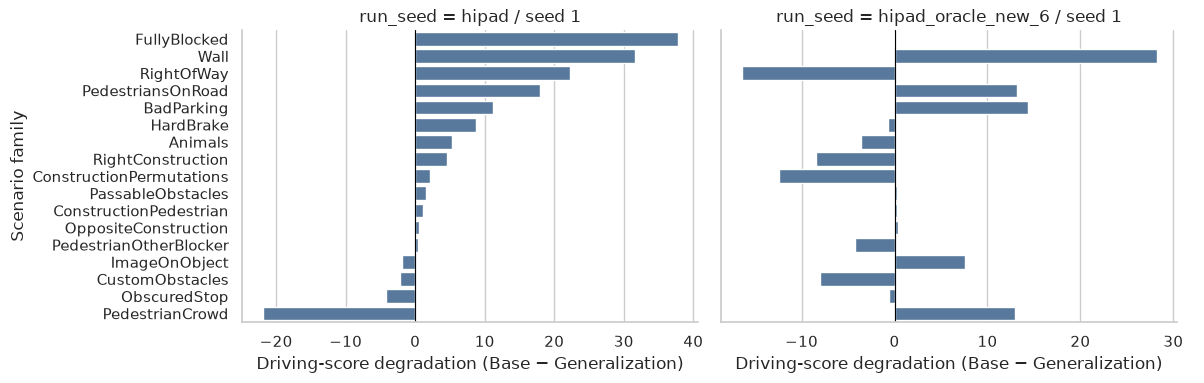

In [5]:
# Plot score degradation for each family. Positive bars are worse on Generalization.
plot_data = degradation.dropna(subset=['driving_score_degradation']).copy()
plot_data['run_seed'] = plot_data['run'] + ' / seed ' + plot_data['seed'].astype(str)

g = sns.catplot(
    data=plot_data, kind='bar', x='driving_score_degradation', y='family',
    col='run_seed', col_wrap=2, sharex=False, height=4, aspect=1.5, color='#4c78a8'
)
g.set_axis_labels('Driving-score degradation (Base − Generalization)', 'Scenario family')
for axis in g.axes.flat:
    axis.axvline(0, color='black', linewidth=0.8)
plt.show()


run,hipad,hipad_oracle_new_6
seed,1,1
family,,
Animals,87.67,84.33
BadParking,60.72,67.43
ConstructionPedestrian,53.51,78.29
ConstructionPermutations,52.42,48.64
CustomObstacles,50.18,59.61
FullyBlocked,38.40,69.89
HardBrake,70.80,73.09
ImageOnObject,56.74,53.85


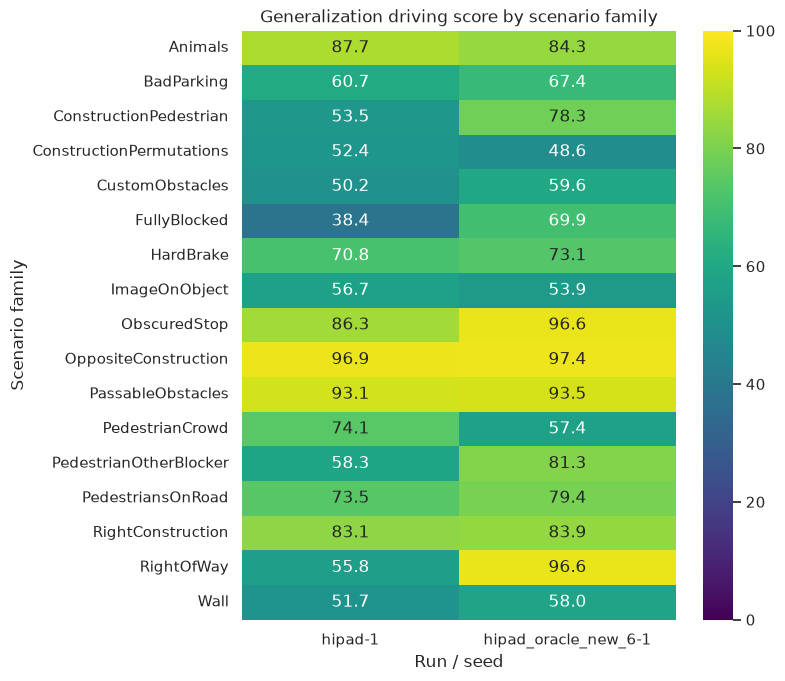

In [6]:
# Compare selected runs directly on the Generalization split.
generalization_by_run = (analysis.query("split == 'Generalization'")
    .groupby(['run', 'seed', 'family'])[METRICS].mean()
    .reset_index())

score_heatmap = generalization_by_run.pivot_table(
    index='family', columns=['run', 'seed'], values='driving_score'
).sort_index()
display(score_heatmap.round(2))

plt.figure(figsize=(max(7, 2 * len(score_heatmap.columns)), max(5, 0.45 * len(score_heatmap))))
sns.heatmap(score_heatmap, annot=True, fmt='.1f', cmap='viridis', vmin=0, vmax=100)
plt.title('Generalization driving score by scenario family')
plt.xlabel('Run / seed')
plt.ylabel('Scenario family')
plt.show()


Paired completed routes: 194
Ignored abs(delta) < 5: 114 | included: 80
Oracle improved: 48 | degraded: 32 | tied: 0
Mean driving-score delta (oracle − vanilla): +12.668


,route_file,driving_score_vanilla,driving_score_oracle,driving_score_delta,route_completion_vanilla,route_completion_oracle,infraction_penalty_vanilla,infraction_penalty_oracle
case_id,,,,,,,,
0079,Base_Animals_0079.xml,97.125,40.990,-56.135,100.00,100.00,0.971,0.410
0069,Base_PedestrianCrowd_0069.xml,45.897,6.492,-39.405,100.00,59.51,0.459,0.109
0093,Base_RightConstruction_0093.xml,94.182,56.585,-37.596,100.00,100.00,0.942,0.566
0037,Base_HardBrake_0037.xml,81.161,45.888,-35.273,100.00,100.00,0.812,0.459
0083,Base_Animals_0083.xml,96.184,61.050,-35.134,100.00,100.00,0.962,0.611
0019,Base_ConstructionPermutations_0019.xml,49.712,17.057,-32.655,100.00,100.00,0.497,0.171
0018,Base_ConstructionPermutations_0018.xml,78.234,49.480,-28.754,100.00,100.00,0.782,0.495
0027,Base_CustomObstacles_0027.xml,79.796,52.946,-26.849,100.00,100.00,0.798,0.529
0016,Base_ConstructionPermutations_0016.xml,48.530,22.373,-26.157,100.00,100.00,0.485,0.224


,route_file,driving_score_vanilla,driving_score_oracle,driving_score_delta,route_completion_vanilla,route_completion_oracle,infraction_penalty_vanilla,infraction_penalty_oracle
case_id,,,,,,,,
0066,Base_PedestrianCrowd_0066.xml,0.000,85.105,85.105,0.00,100.0,0.650,0.851
1059,Generalization_RightOfWay_1059.xml,24.466,99.022,74.556,63.31,100.0,0.386,0.990
0048,Base_ObscuredStop_0048.xml,26.932,99.319,72.387,84.32,100.0,0.319,0.993
1073,Generalization_PedestrianOtherBlocker_1073.xml,21.610,89.007,67.397,100.00,100.0,0.216,0.890
1020,Generalization_CustomObstacles_1020.xml,13.491,77.503,64.012,29.65,100.0,0.455,0.775
0013,Base_ConstructionPedestrian_0013.xml,21.914,85.060,63.146,100.00,100.0,0.219,0.851
0005,Base_BadParking_0005.xml,36.694,97.768,61.074,100.00,100.0,0.367,0.978
1013,Generalization_ConstructionPedestrian_1013.xml,31.970,88.618,56.648,47.90,100.0,0.667,0.886
0070,Base_PedestrianOtherBlocker_0070.xml,38.587,95.181,56.594,100.00,100.0,0.386,0.952


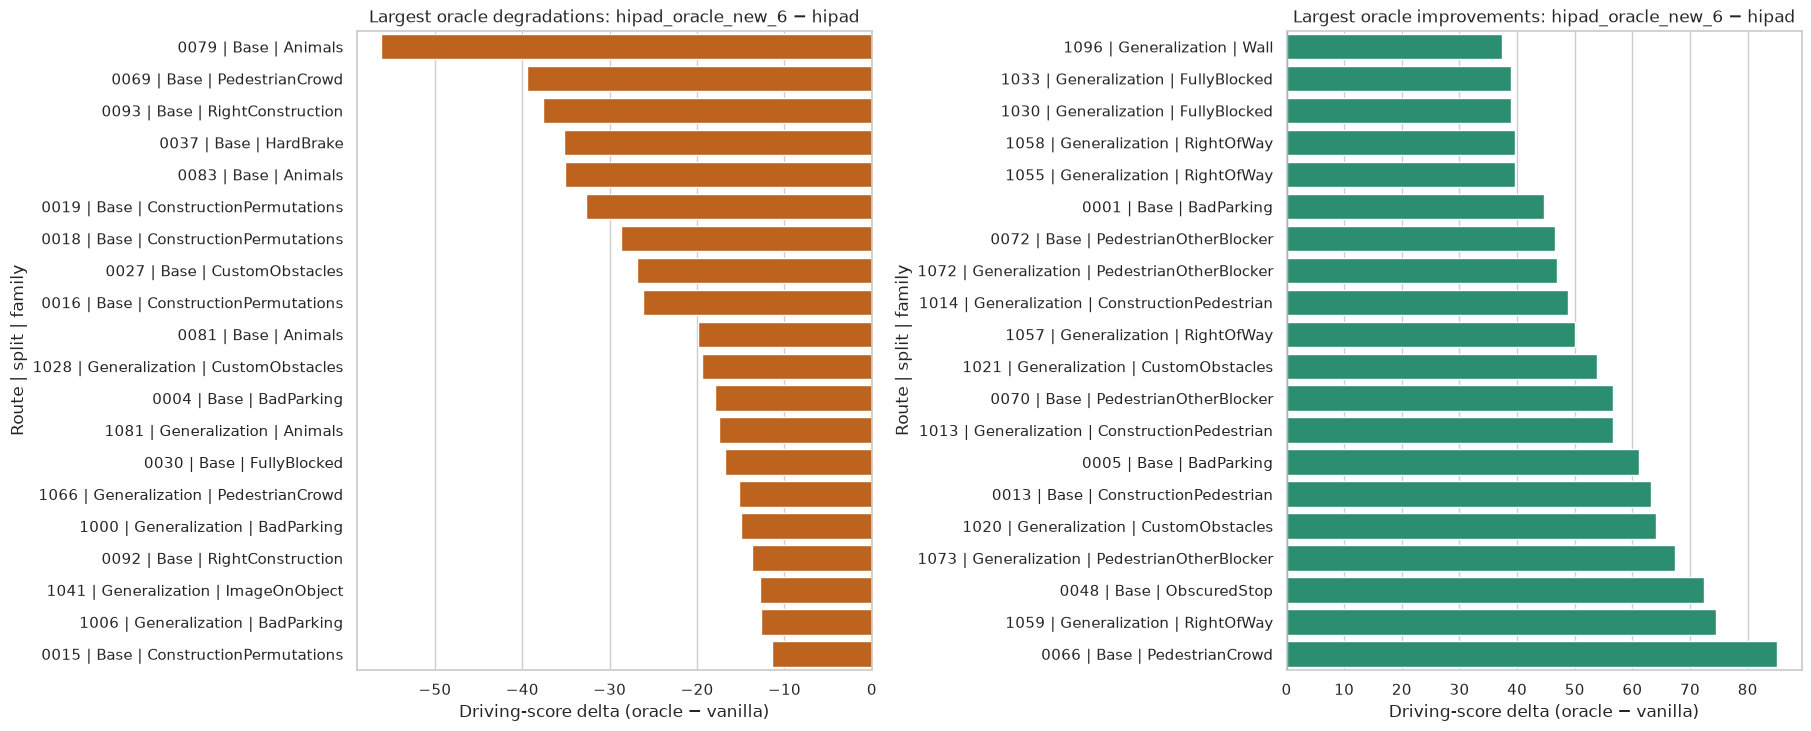

In [7]:
# Route-level vanilla vs oracle comparison.
# Change ORACLE_RUN to compare a different oracle experiment.
VANILLA_RUN = 'hipad'
ORACLE_RUN = 'hipad_oracle_new_6'
COMPARE_SEED = 1
TOP_N = 20
MIN_ABS_SCORE_DELTA = 5.0  # Ignore route changes smaller than this threshold.

pair_source = analysis.query('seed == @COMPARE_SEED and run in [@VANILLA_RUN, @ORACLE_RUN]')
metadata_columns = ['case_id', 'route_file', 'split', 'family']
metric_columns = ['driving_score', 'route_completion', 'infraction_penalty']
vanilla = (pair_source.query('run == @VANILLA_RUN')[metadata_columns + metric_columns]
    .drop_duplicates('case_id').set_index('case_id'))
oracle = (pair_source.query('run == @ORACLE_RUN')[['case_id'] + metric_columns]
    .drop_duplicates('case_id').set_index('case_id'))
route_comparison = vanilla.join(oracle, how='inner', lsuffix='_vanilla', rsuffix='_oracle')
for metric in metric_columns:
    route_comparison[f'{metric}_delta'] = route_comparison[f'{metric}_oracle'] - route_comparison[f'{metric}_vanilla']
route_comparison['route_label'] = route_comparison.index + ' | ' + route_comparison['split'] + ' | ' + route_comparison['family']

meaningful_comparison = route_comparison.loc[route_comparison['driving_score_delta'].abs() >= MIN_ABS_SCORE_DELTA].copy()
score_delta = meaningful_comparison['driving_score_delta']
print(f'Paired completed routes: {len(route_comparison)}')
print(f'Ignored abs(delta) < {MIN_ABS_SCORE_DELTA:g}: {len(route_comparison) - len(meaningful_comparison)} | included: {len(meaningful_comparison)}')
print(f'Oracle improved: {(score_delta > 0).sum()} | degraded: {(score_delta < 0).sum()} | tied: {(score_delta == 0).sum()}')
print(f'Mean driving-score delta (oracle − vanilla): {score_delta.mean():+.3f}')

display_columns = ['route_file', 'driving_score_vanilla', 'driving_score_oracle', 'driving_score_delta', 'route_completion_vanilla', 'route_completion_oracle', 'infraction_penalty_vanilla', 'infraction_penalty_oracle']
display(meaningful_comparison.sort_values('driving_score_delta')[display_columns].round(3).head(TOP_N))
display(meaningful_comparison.sort_values('driving_score_delta', ascending=False)[display_columns].round(3).head(TOP_N))

worst = meaningful_comparison.nsmallest(TOP_N, 'driving_score_delta').sort_values('driving_score_delta')
best = meaningful_comparison.nlargest(TOP_N, 'driving_score_delta').sort_values('driving_score_delta')
fig, axes = plt.subplots(1, 2, figsize=(18, max(6, TOP_N * 0.36)), constrained_layout=True)
sns.barplot(data=worst, x='driving_score_delta', y='route_label', ax=axes[0], color='#d95f02')
sns.barplot(data=best, x='driving_score_delta', y='route_label', ax=axes[1], color='#1b9e77')
axes[0].set_title(f'Largest oracle degradations: {ORACLE_RUN} − {VANILLA_RUN}')
axes[1].set_title(f'Largest oracle improvements: {ORACLE_RUN} − {VANILLA_RUN}')
for axis in axes:
    axis.axvline(0, color='black', linewidth=0.8)
    axis.set_xlabel('Driving-score delta (oracle − vanilla)')
    axis.set_ylabel('Route | split | family')
plt.show()


In [8]:
# Route-level inspection: use this to investigate the largest regressions.
route_columns = ['run', 'seed', 'case_id', 'route_file', 'split', 'family'] + METRICS + [
    'collisions_vehicle', 'collisions_pedestrian', 'collisions_layout', 'min_speed_infractions'
] # route_file
worst_routes = analysis.sort_values('driving_score')[route_columns].head(30)
display(worst_routes.round(3))

# Optional exports for reports.
# degradation.to_csv(PROJECT_ROOT / 'results_base_vs_generalization.csv', index=False)
# results.to_csv(PROJECT_ROOT / 'results_route_level.csv', index=False)


,run,seed,case_id,route_file,split,family,driving_score,route_completion,infraction_penalty,collisions_vehicle,collisions_pedestrian,collisions_layout,min_speed_infractions
66,hipad,1,0066,Base_PedestrianCrowd_0066.xml,Base,PedestrianCrowd,0.000,0.00,0.650,0.000,0.000,1000.000,0.000
40,hipad,1,0040,Base_ImageOnObject_0040.xml,Base,ImageOnObject,1.611,29.04,0.055,57.547,0.000,0.000,19.182
369,hipad_oracle_new_6,1,1069,Generalization_PedestrianCrowd_1069.xml,Generalization,PedestrianCrowd,2.536,73.86,0.034,6.937,0.000,34.686,13.874
215,hipad_oracle_new_6,1,0015,Base_ConstructionPermutations_0015.xml,Base,ConstructionPermutations,4.071,100.00,0.041,6.990,0.000,3.495,17.475
140,hipad,1,1040,Generalization_ImageOnObject_1040.xml,Generalization,ImageOnObject,5.343,100.00,0.053,22.282,0.000,0.000,11.141
269,hipad_oracle_new_6,1,0069,Base_PedestrianCrowd_0069.xml,Base,PedestrianCrowd,6.492,59.51,0.109,0.000,0.000,25.830,17.220
131,hipad,1,1031,Generalization_FullyBlocked_1031.xml,Generalization,FullyBlocked,8.962,100.00,0.090,3.060,0.000,12.241,3.060
340,hipad_oracle_new_6,1,1040,Generalization_ImageOnObject_1040.xml,Generalization,ImageOnObject,9.180,100.00,0.092,16.712,0.000,0.000,11.141
341,hipad_oracle_new_6,1,1041,Generalization_ImageOnObject_1041.xml,Generalization,ImageOnObject,10.149,43.48,0.233,0.000,0.000,12.269,12.269
120,hipad,1,1020,Generalization_CustomObstacles_1020.xml,Generalization,CustomObstacles,13.491,29.65,0.455,0.000,0.000,18.826,0.000


In [9]:
# Routes where both vanilla and oracle perform poorly.
BAD_SCORE_THRESHOLD = 50.0
TOP_N = 30

both_poor = route_comparison.loc[
    (route_comparison['driving_score_vanilla'] <= BAD_SCORE_THRESHOLD) &
    (route_comparison['driving_score_oracle'] <= BAD_SCORE_THRESHOLD)
].copy()

both_poor['mean_driving_score'] = (
    both_poor['driving_score_vanilla'] + both_poor['driving_score_oracle']
) / 2

display_columns = [
    'route_file', 'split', 'family',
    'driving_score_vanilla', 'driving_score_oracle',
    'driving_score_delta', 'mean_driving_score',
    'route_completion_vanilla', 'route_completion_oracle',
    'infraction_penalty_vanilla', 'infraction_penalty_oracle',
]

display(
    both_poor.sort_values('mean_driving_score')
    [display_columns]
    .head(TOP_N)
    .round(3)
)

,route_file,split,family,driving_score_vanilla,driving_score_oracle,driving_score_delta,mean_driving_score,route_completion_vanilla,route_completion_oracle,infraction_penalty_vanilla,infraction_penalty_oracle
case_id,,,,,,,,,,,
1040,Generalization_ImageOnObject_1040.xml,Generalization,ImageOnObject,5.343,9.180,3.837,7.262,100.00,100.00,0.053,0.092
0015,Base_ConstructionPermutations_0015.xml,Base,ConstructionPermutations,15.490,4.071,-11.419,9.781,33.15,100.00,0.467,0.041
0040,Base_ImageOnObject_0040.xml,Base,ImageOnObject,1.611,22.273,20.662,11.942,29.04,100.00,0.055,0.223
1022,Generalization_CustomObstacles_1022.xml,Generalization,CustomObstacles,14.311,14.311,0.000,14.311,31.92,31.92,0.448,0.448
1015,Generalization_ConstructionPermutations_1015.xml,Generalization,ConstructionPermutations,13.746,18.917,5.171,16.331,28.57,37.73,0.481,0.501
1041,Generalization_ImageOnObject_1041.xml,Generalization,ImageOnObject,22.997,10.149,-12.848,16.573,45.10,43.48,0.510,0.233
0021,Base_CustomObstacles_0021.xml,Base,CustomObstacles,21.276,13.885,-7.390,17.580,100.00,31.09,0.213,0.447
0041,Base_ImageOnObject_0041.xml,Base,ImageOnObject,20.860,17.032,-3.827,18.946,100.00,36.99,0.209,0.460
1080,Generalization_Animals_1080.xml,Generalization,Animals,23.059,24.680,1.621,23.869,100.00,62.98,0.231,0.392
